# LSST Time-Series Classification — Training on Colab

**Models**: InceptionTime · PatchTST · UniTS · Chronos-2 · MOMENT

Run cells top-to-bottom.  GPU runtime required (Runtime > Change runtime type > T4 GPU).

## 1. Environment Setup

We first clone our repo and setup the environment using `uv`.

In [1]:
!pwd

/content


In [3]:
!rm -rf TimeSeriesClassification/
!git clone https://github.com/coulzie031/TimeSeriesClassification.git

Cloning into 'dlts'...
remote: Enumerating objects: 230, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (119/119), done.
remote: Total 230 (delta 125), reused 187 (delta 85), pack-reused 0 (from 0)
Receiving objects: 100% (230/230), 195.25 KiB | 6.97 MiB/s, done.
Resolving deltas: 100% (125/125), done.


In [4]:
%cd TimeSeriesClassification/

/content/dlts


In [26]:
# !git pull

In [14]:
!uv sync

Resolved 109 packages in 1ms
Audited 104 packages in 65ms


In [6]:
# confirm GPU is available before training
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))

CUDA available: True
Device: Tesla T4


## 2. Weights & Biases Login (Optional)

In [ ]:
import wandb
wandb.init(mode="disabled")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Train Models

Each command loads a fully self-contained config from `cfg/`.
Checkpoints and sidecar JSON files are written to `checkpoints/`.

### 3.1 InceptionTime (baseline)

In [27]:
!uv run python -m dlts.train --cfg cfg/inception_time.yaml --wandb.mode offline

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ setting up run 3euw4csi (0.0s)
wandb: ⣻ setting up run 3euw4csi (0.0s)
wandb: ⣽ setting up run 3euw4csi (0.0s)
wandb: ⣾ setting up run 3euw4csi (0.3s)
wandb: ⣷ setting up run 3euw4csi (0.3s)
wandb: ⣯ setting up run 3euw4csi (0.3s)
wandb: ⣟ setting up run 3euw4csi (0.3s)
wandb: ⡿ setting up run 3euw4csi (0.3s)
wandb: ⢿ setting up run 3euw4csi (0.8s)
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /content/dlts/wandb/run-20260316_204623-3euw4csi
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run inception_time
wandb: ⭐️ View project at https://wandb.ai/clijo-jose/lsst-tsfm
wandb: 🚀 View run at https://wandb.ai/clijo-jose/lsst-tsfm/runs/3euw4csi

>>> [SCRATCH] Training

In [29]:
!uv run python -m dlts.eval --checkpoint_dir checkpoints/ --model inception_time

Device: cuda

Model  : inception_time
Val F1 : 0.4559  (from training run)

Loading LSST test set...
Loading checkpoint: checkpoints/inception_time_stage1_best.pt

── Test metrics ─────────────────────────────────────────
  Accuracy          : 0.3544
  Macro F1          : 0.4018
  Balanced Accuracy : 0.4774
  Log-Loss          : 1.8787

── Per-class F1 ─────────────────────────────────────────
     Class      F1   Support
  --------  ------  --------
         6  0.4000        35
        15  0.5476       124
        16  0.8138       270
        42  0.2038       382
        52  0.1316        63
        53  0.0148         7
        62  0.2143       153
        64  0.0920        24
        65  0.6358       313
        67  0.2403        68
        88  0.8861       121
        90  0.1745       777
        92  0.9281        77
        95  0.3429        52
  --------  ------  --------
     macro  0.4018      2466

Confusion matrix saved -> checkpoints/inception_time_confusion_matrix.png

# To 

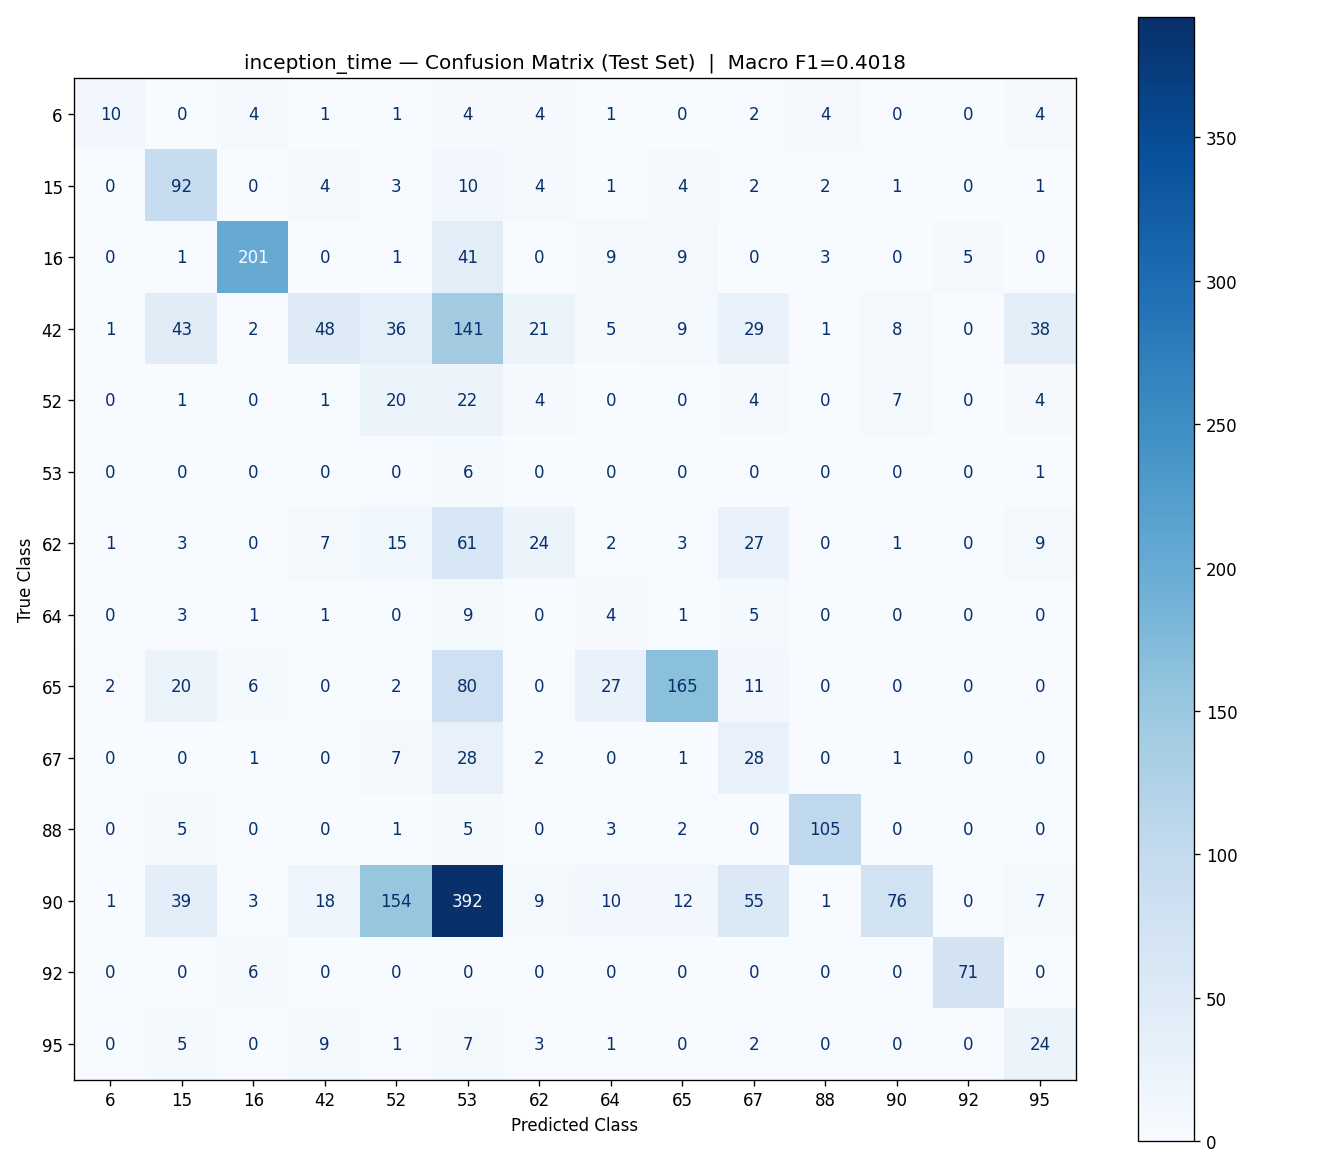

In [36]:
import IPython.display
IPython.display.display(IPython.display.Image("checkpoints/inception_time_confusion_matrix.png"))

### 3.2 PatchTST

In [28]:
!uv run python -m dlts.train --cfg cfg/patch_tst.yaml --wandb.mode offline

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run vpzhghtk (0.3s)
wandb: ⣷ setting up run vpzhghtk (0.3s)
wandb: ⣯ setting up run vpzhghtk (0.3s)
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /content/dlts/wandb/run-20260316_204821-vpzhghtk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run patch_tst
wandb: ⭐️ View project at https://wandb.ai/clijo-jose/lsst-tsfm
wandb: 🚀 View run at https://wandb.ai/clijo-jose/lsst-tsfm/runs/vpzhghtk

>>> [SCRATCH] Training patch_tst end-to-end
[train] epoch=1/200 loss=3.3241 val_acc=0.0325 val_f1=0.0350 val_bal_acc=0.1012 val_logloss=2.5381 best_val_f1=0

In [30]:
!uv run python -m dlts.eval --checkpoint_dir checkpoints/ --model patch_tst

Device: cuda

Model  : patch_tst
Val F1 : 0.4383  (from training run)

Loading LSST test set...
Loading checkpoint: checkpoints/patch_tst_stage1_best.pt

── Test metrics ─────────────────────────────────────────
  Accuracy          : 0.4124
  Macro F1          : 0.3879
  Balanced Accuracy : 0.4221
  Log-Loss          : 1.8292

── Per-class F1 ─────────────────────────────────────────
     Class      F1   Support
  --------  ------  --------
         6  0.2973        35
        15  0.4821       124
        16  0.8919       270
        42  0.4086       382
        52  0.1264        63
        53  0.0128         7
        62  0.1455       153
        64  0.0690        24
        65  0.7717       313
        67  0.2390        68
        88  0.8861       121
        90  0.3419       777
        92  0.4818        77
        95  0.2763        52
  --------  ------  --------
     macro  0.3879      2466

Confusion matrix saved -> checkpoints/patch_tst_confusion_matrix.png

# To display in Cola

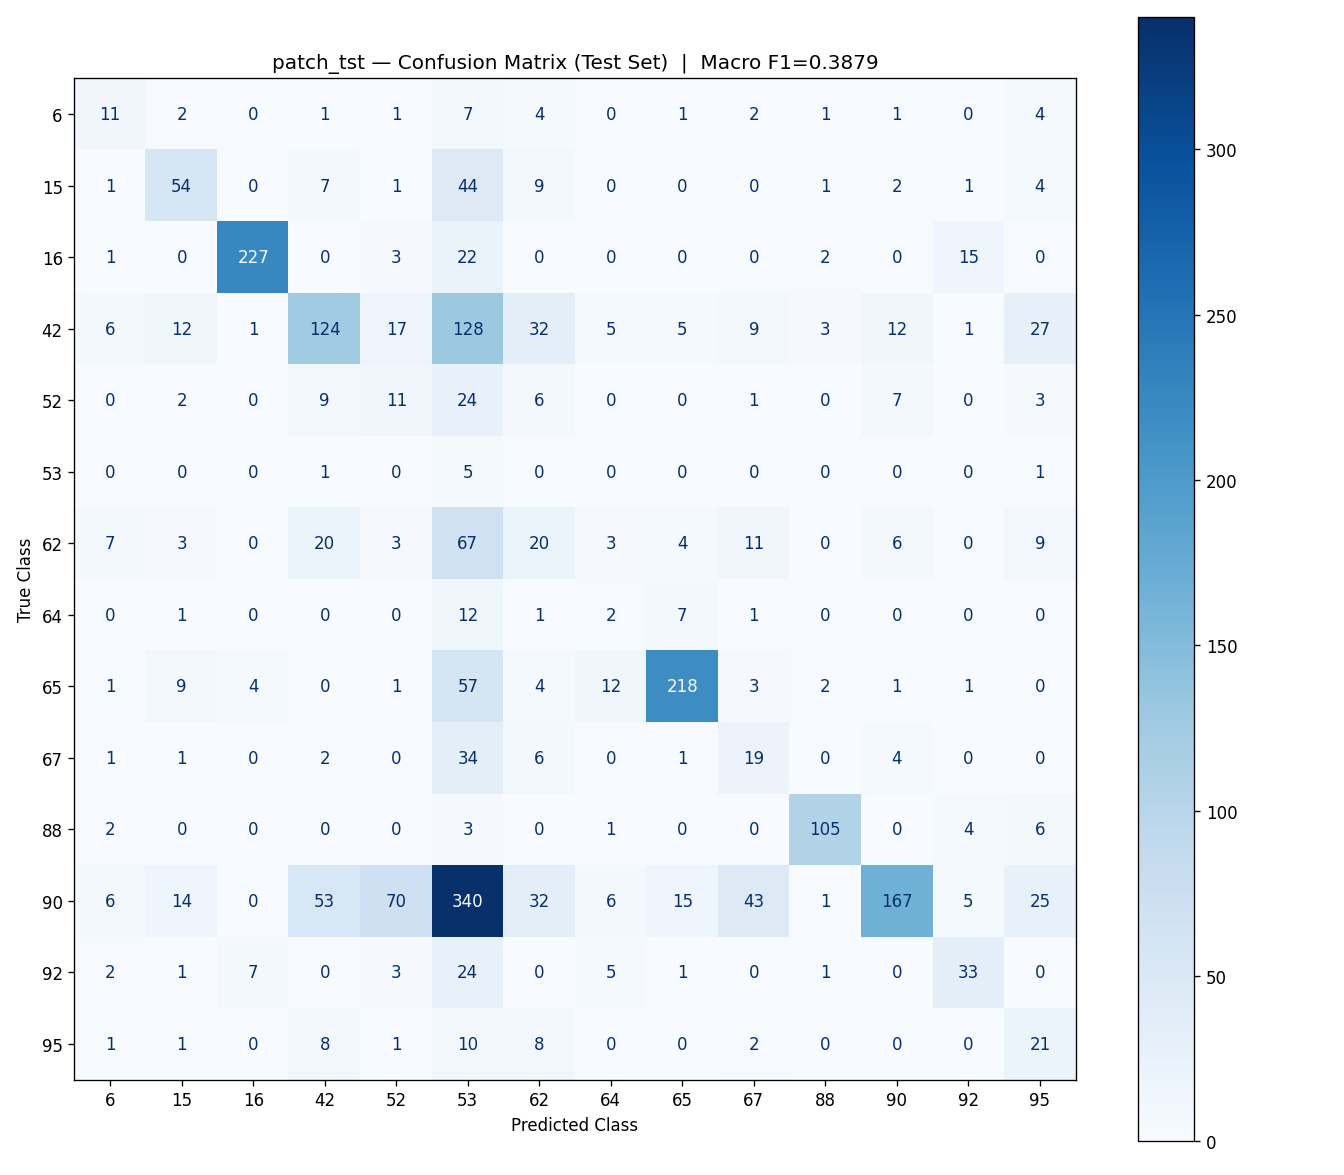

In [37]:
import IPython.display
IPython.display.display(IPython.display.Image("checkpoints/patch_tst_confusion_matrix.png"))

### 3.3 UniTS

In [31]:
!uv run python -m dlts.train --cfg cfg/units.yaml --wandb.mode offline

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run a2w4ux8i (0.3s)
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /content/dlts/wandb/run-20260316_205127-a2w4ux8i
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run units
wandb: ⭐️ View project at https://wandb.ai/clijo-jose/lsst-tsfm
wandb: 🚀 View run at https://wandb.ai/clijo-jose/lsst-tsfm/runs/a2w4ux8i

>>> [SCRATCH] Training units end-to-end
[train] epoch=1/200 loss=3.3563 val_acc=0.0081 val_f1=0.0083 val_bal_acc=0.0286 val_logloss=2.7401 best_val_f1=0.0083
[train] epoch=2/200 loss=3.3561 val_acc=0.0020 val_f1=0.0003 val_bal_acc=0.0714 va

In [32]:
!uv run python -m dlts.eval --checkpoint_dir checkpoints/ --model units

Device: cuda

Model  : units
Val F1 : 0.3432  (from training run)

Loading LSST test set...
Loading checkpoint: checkpoints/units_stage1_best.pt

── Test metrics ─────────────────────────────────────────
  Accuracy          : 0.2587
  Macro F1          : 0.2950
  Balanced Accuracy : 0.4185
  Log-Loss          : 2.0959

── Per-class F1 ─────────────────────────────────────────
     Class      F1   Support
  --------  ------  --------
         6  0.2190        35
        15  0.4625       124
        16  0.8202       270
        42  0.0000       382
        52  0.0531        63
        53  0.0169         7
        62  0.0636       153
        64  0.0532        24
        65  0.4688       313
        67  0.1333        68
        88  0.6797       121
        90  0.0000       777
        92  0.8166        77
        95  0.3429        52
  --------  ------  --------
     macro  0.2950      2466

Confusion matrix saved -> checkpoints/units_confusion_matrix.png

# To display in Colab after this

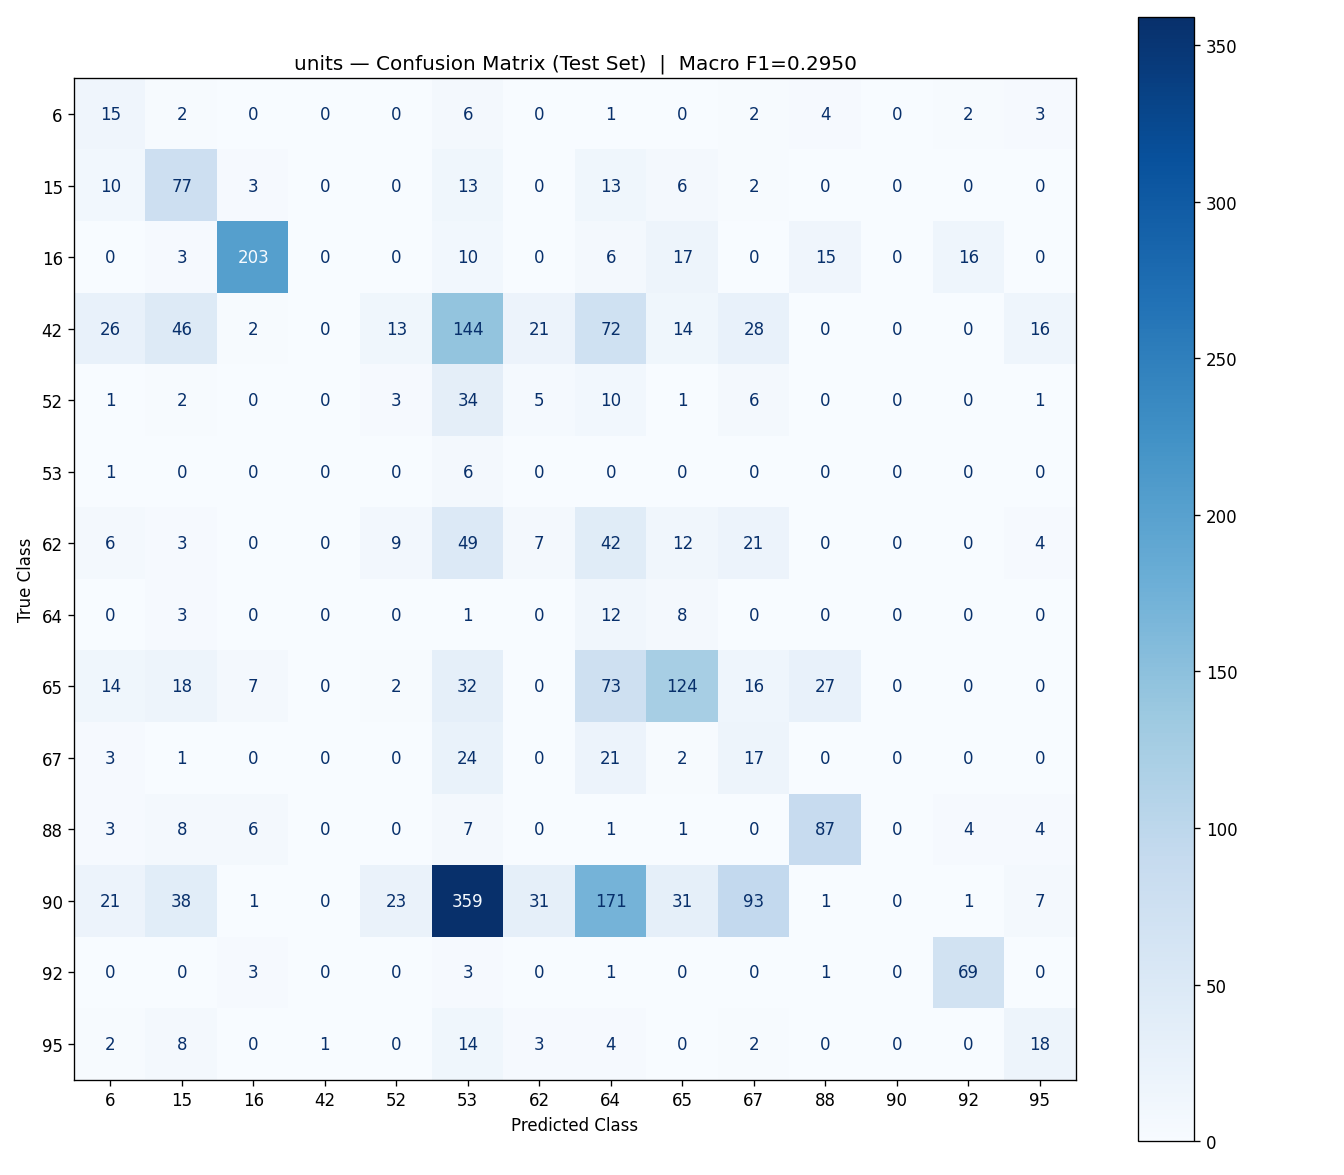

In [38]:
import IPython.display
IPython.display.display(IPython.display.Image("checkpoints/units_confusion_matrix.png"))

### 3.4 Chronos-2 (foundation model — LP then FT)

In [33]:
!uv run python -m dlts.train --cfg cfg/chronos.yaml --wandb.mode offline

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: ⢿ Waiting for wandb.init()...
wandb: ⣻ Waiting for wandb.init()...
wandb: ⣽ Waiting for wandb.init()...
wandb: ⣾ setting up run mhc32t6d (0.3s)
wandb: ⣷ setting up run mhc32t6d (0.3s)
wandb: ⣯ setting up run mhc32t6d (0.3s)
wandb: ⣟ setting up run mhc32t6d (0.3s)
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /content/dlts/wandb/run-20260316_205357-mhc32t6d
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run chronos2_adaptation
wandb: ⭐️ View project at https://wandb.ai/clijo-jose/lsst-tsfm
wandb: 🚀 View run at https://wandb.ai/clijo-jose/lsst-tsfm/runs/mhc32t6d

>>> [FOUNDATION] Adapting chronos via 2-Stage LP-FT
>>> Stage 1: Freezing backbone for head-only warmup...

In [34]:
!uv run python -m dlts.eval --checkpoint_dir checkpoints/ --model chronos

Device: cuda

Model  : chronos
Val F1 : 0.3291  (from training run)

Loading LSST test set...
Loading checkpoint: checkpoints/chronos_stage2_best.pt

── Test metrics ─────────────────────────────────────────
  Accuracy          : 0.3045
  Macro F1          : 0.3202
  Balanced Accuracy : 0.4245
  Log-Loss          : 1.9025

── Per-class F1 ─────────────────────────────────────────
     Class      F1   Support
  --------  ------  --------
         6  0.2667        35
        15  0.2614       124
        16  0.9062       270
        42  0.0052       382
        52  0.0924        63
        53  0.0114         7
        62  0.0000       153
        64  0.1260        24
        65  0.7509       313
        67  0.1612        68
        88  0.8841       121
        90  0.0000       777
        92  0.7805        77
        95  0.2367        52
  --------  ------  --------
     macro  0.3202      2466

Confusion matrix saved -> checkpoints/chronos_confusion_matrix.png

# To display in Colab afte

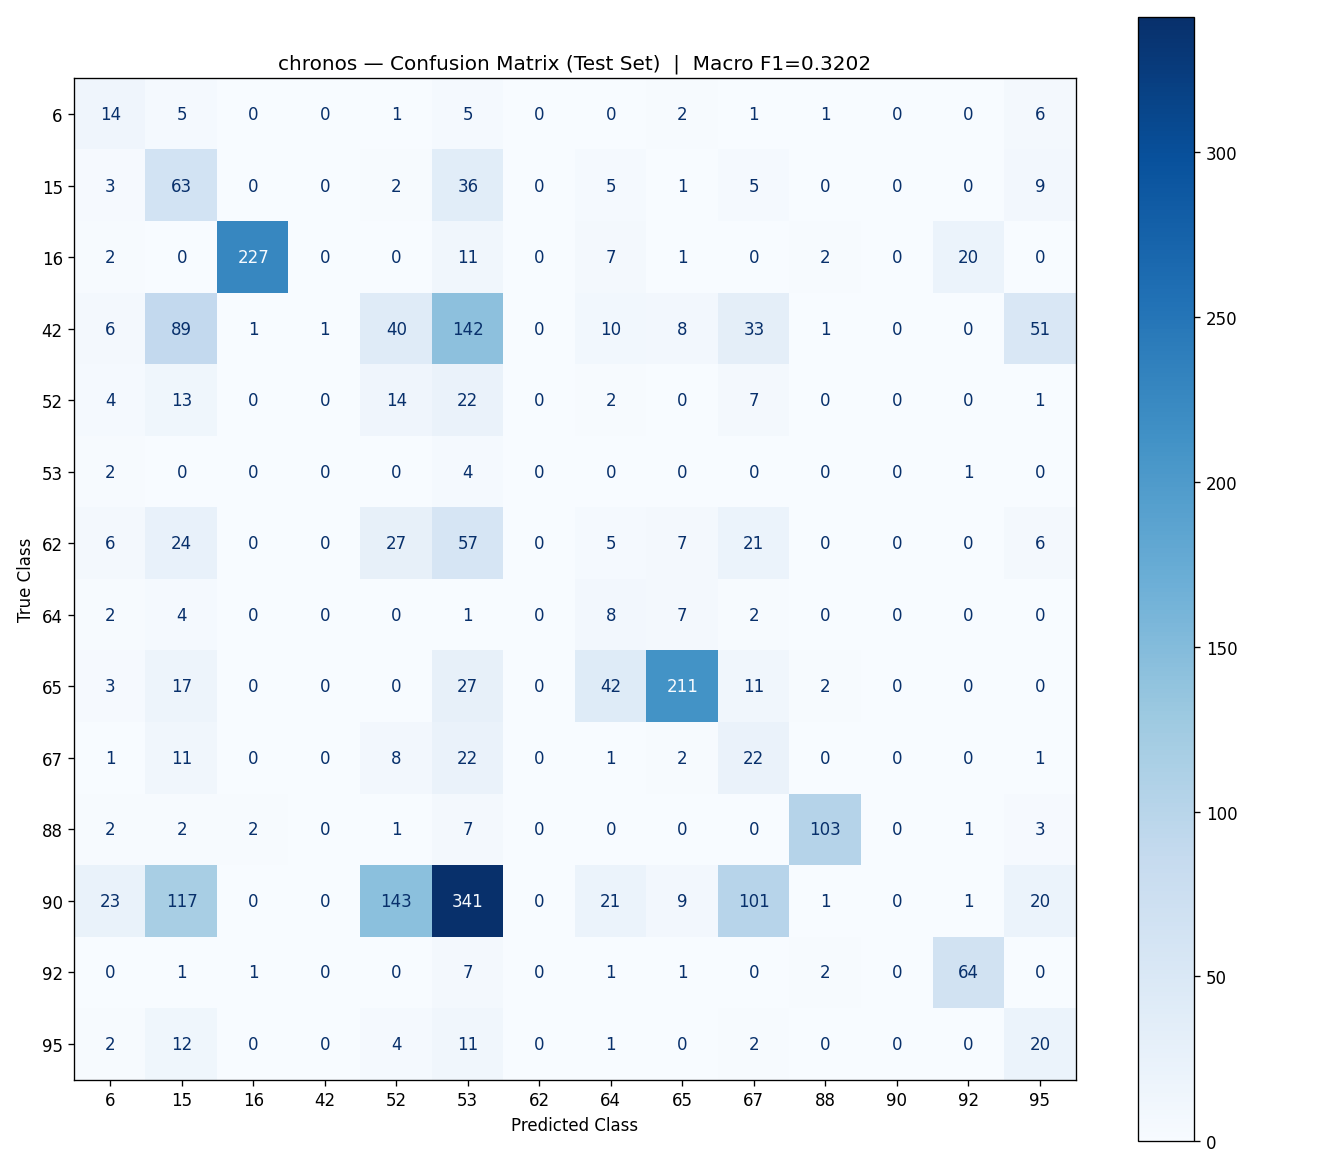

In [39]:
import IPython.display
IPython.display.display(IPython.display.Image("checkpoints/chronos_confusion_matrix.png"))

### 3.5 MOMENT (foundation model — LP then FT)

In [12]:
!uv run python -m dlts.train --cfg cfg/moment.yaml --wandb.mode offline

Split: 1967 train / 492 val / 2466 test  (val_fraction=0.2)
config.json: 2.88kB [00:00, 9.75MB/s]
configuration_moment.py: 3.20kB [00:00, 10.8MB/s]
A new version of the following files was downloaded from https://huggingface.co/HachiML/MOMENT-1-large-embedding-v0.1:
- configuration_moment.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
modeling_moment.py: 21.5kB [00:00, 20.6MB/s]
A new version of the following files was downloaded from https://huggingface.co/HachiML/MOMENT-1-large-embedding-v0.1:
- modeling_moment.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
model.safetensors: 100% 1.39G/1.39G [00:15<00:00, 92.2MB/s]
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: clijo (clijo-jose) to https://api.wandb.ai. 

In [35]:
!uv run python -m dlts.eval --checkpoint_dir checkpoints/ --model moment

Device: cuda

Model  : moment
Val F1 : 0.2948  (from training run)

Loading LSST test set...
Loading checkpoint: checkpoints/moment_stage2_best.pt

── Test metrics ─────────────────────────────────────────
  Accuracy          : 0.3118
  Macro F1          : 0.2962
  Balanced Accuracy : 0.3865
  Log-Loss          : 1.9856

── Per-class F1 ─────────────────────────────────────────
     Class      F1   Support
  --------  ------  --------
         6  0.1481        35
        15  0.2119       124
        16  0.8682       270
        42  0.2620       382
        52  0.1048        63
        53  0.0191         7
        62  0.0818       153
        64  0.0874        24
        65  0.7210       313
        67  0.0711        68
        88  0.8430       121
        90  0.0710       777
        92  0.5176        77
        95  0.1402        52
  --------  ------  --------
     macro  0.2962      2466

Confusion matrix saved -> checkpoints/moment_confusion_matrix.png

# To display in Colab after t

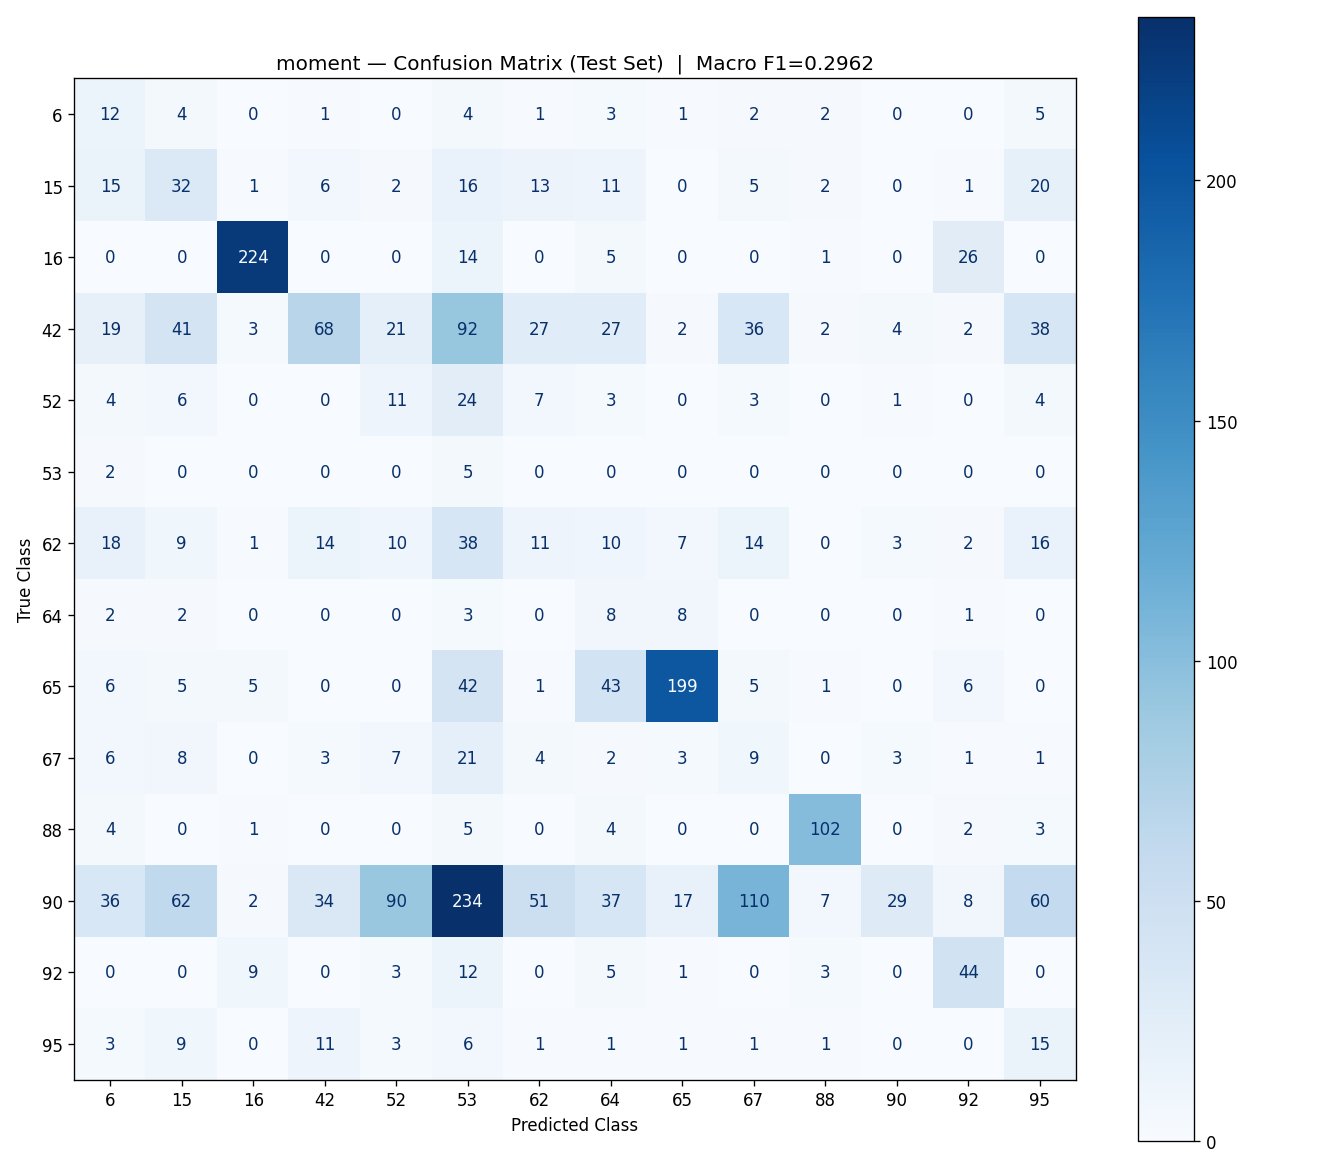

In [40]:
import IPython.display
IPython.display.display(IPython.display.Image("checkpoints/moment_confusion_matrix.png"))

## 4. Ensemble

Soft-voting ensemble weighted by each model's validation macro-F1.
Models below `--min_val_f1` are automatically excluded.
Result is written to `checkpoints/ensemble_result.json`.

In [43]:
!uv run python -m dlts.ensemble \n    --checkpoint_dir checkpoints/ \n    --min_val_f1 0.30 \n    --temperature 10.0 \n    --n_tta 5

Device: cuda

Found 5 run(s), 4 eligible (val F1 ≥ 0.3).
  [EXCLUDED] moment                val_f1=0.2948

Loading LSST test set...

Loading  chronos               val_f1=0.3291 ...
  -> test_acc=0.3045  test_f1=0.3202  test_bal_acc=0.4245
Loading  inception_time        val_f1=0.4559 ...
  -> test_acc=0.3544  test_f1=0.4018  test_bal_acc=0.4774
Loading  patch_tst             val_f1=0.4383 ...
  -> test_acc=0.4124  test_f1=0.3879  test_bal_acc=0.4221
Loading  units                 val_f1=0.3432 ...
  -> test_acc=0.2587  test_f1=0.2950  test_bal_acc=0.4185

── Ensemble weights ─────────────────────────────────────
  chronos               val_f1=0.3291  weight=0.1152
  inception_time        val_f1=0.4559  weight=0.4092
  patch_tst             val_f1=0.4383  weight=0.3431
  units                 val_f1=0.3432  weight=0.1325

── Ensemble result ──────────────────────────────────────
  Accuracy          : 0.4298
  Macro F1          : 0.4593
  Balanced Accuracy : 0.5273
  Log-Loss          : 

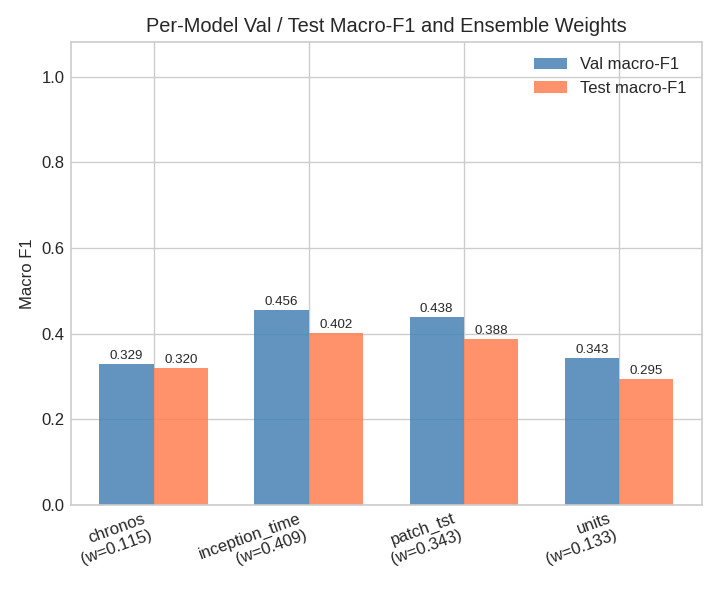

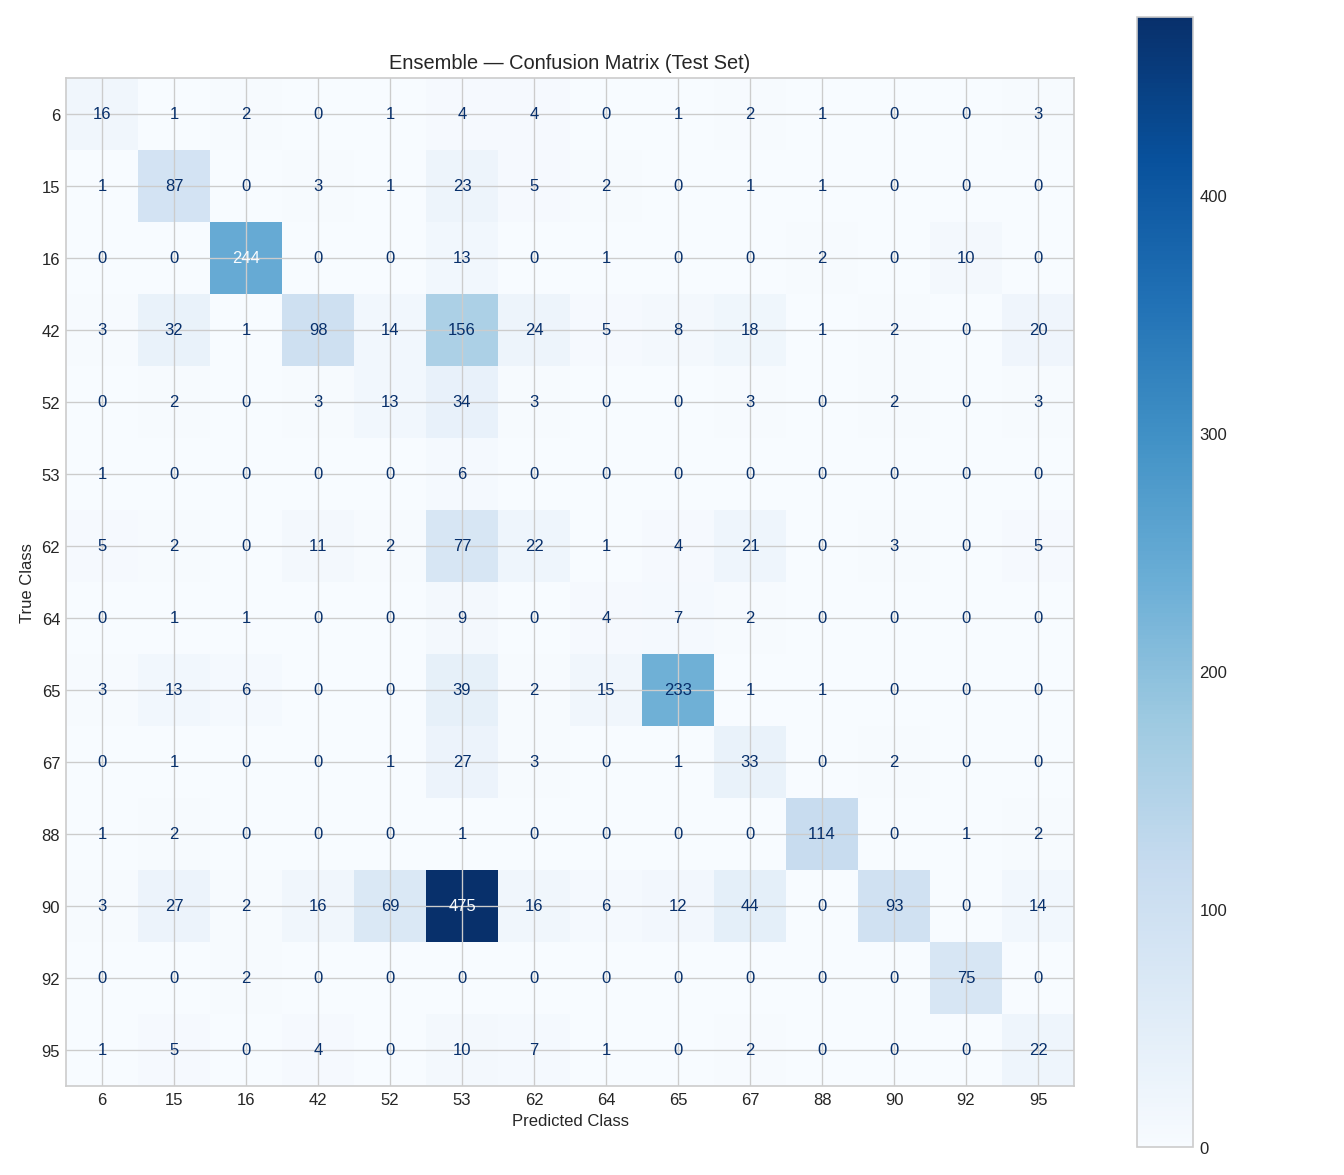

In [44]:
import IPython.display

IPython.display.display(
    IPython.display.Image("checkpoints/ensemble_model_comparison.png")
)
IPython.display.display(
    IPython.display.Image("checkpoints/ensemble_confusion_matrix.png")
)